In [2]:
# Fix: Install Pre-Built Wheels (No Build from Source)
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.1.0+cu121.html --no-cache-dir

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 223.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 325.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 337.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.0/936.0 kB 352.5 MB/s eta 0:00:00


In [4]:
!pip install lifelines --no-cache-dir

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 317.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=d1d44913bec10f57949bf319114d86856993610754aa4cbb7304fe7b5f0be38b
  Stored in directory: /tmp/pip-ephem-wheel-cache-sptin73i/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader as GraphDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import from_networkx
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import re
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, f1_score
from lifelines.utils import concordance_index
from fuzzywuzzy import process
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from torch.nn import LSTM
import logging
from transformers import logging as tf_logging
tf_logging.set_verbosity_error()
import tqdm
tqdm.tqdm.disable = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print("Torch-Geometric imported successfully!")

Using device: cuda
Torch-Geometric imported successfully!


/usr/local/lib/python3.11/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [7]:
# Step 1: Load and Preprocess Data (Metadata-Based Cancer Type - 0% Unknowns)
import logging
from transformers import logging as tf_logging
tf_logging.set_verbosity_error()
import tqdm
tqdm.tqdm.disable = True

df = pd.read_csv('/kaggle/input/tcga-csv/TCGA_Reports.csv')  # Adjust path
df = df.rename(columns={'text': 'extracted_text', 'patient_filename': 'uuid'})

def clean_text(text):
    text = re.sub(r'\s+', ' ', text.strip())
    date_match = re.search(r'\d{1,2}/\d{1,2}/\d{4}', text)
    date = datetime.strptime(date_match.group(), '%m/%d/%Y') if date_match else None
    return text, date

df[['clean_text', 'report_date']] = df['extracted_text'].apply(lambda x: pd.Series(clean_text(x)))

# Dummy labels (replace with TCGA fetch)
df['survival_label'] = np.random.randint(0, 2, size=len(df))
df['survival_time'] = np.random.uniform(1, 120, size=len(df))

# FIXED: Load metadata CSV
metadata = pd.read_csv('/kaggle/input/tcga-metadata/tcga_patient_to_cancer_type.csv')  # Adjust path to your CSV
metadata = metadata.rename(columns={'patient_id': 'short_uuid', 'cancer_type': 'cancer_type_tcga'})

# Extract short UUID from df['uuid'] (first 12 chars: TCGA-XX-XXXX)
df['short_uuid'] = df['uuid'].str[:12]

# Merge on short_uuid to get cancer_type_tcga
df = df.merge(metadata, on='short_uuid', how='left')

# Add old keyword-based cancer_type for comparison
def infer_cancer_type(text):
    keywords = {'colon': 'Colon', 'thyroid': 'Thyroid', 'bladder': 'Bladder', 'prostate': 'Prostate', 'brain': 'Brain'}
    for k, v in keywords.items():
        if k in text.lower():
            return v
    return 'Unknown'
df['cancer_type'] = df['clean_text'].apply(infer_cancer_type)

# FIXED: Print only existing columns (removed 'project')
print(df[['uuid', 'cancer_type', 'short_uuid', 'cancer_type_tcga']].head(10))
print("\nOld Keyword Cancer Types:\n", df['cancer_type'].value_counts().head(10))
print("\nTCGA Cancer Types (Improved):\n", df['cancer_type_tcga'].value_counts().head(10))
print(f"Unknowns in TCGA cancer_type_tcga: {df['cancer_type_tcga'].isna().sum()} ({df['cancer_type_tcga'].isna().sum() / len(df) * 100:.1f}%)")

                                                uuid cancer_type  \
0  TCGA-BP-5195.25c0b433-5557-4165-922e-2c1eac9c26f0     Unknown   
1  TCGA-D7-8573.b7306a47-697d-4ed3-bbe1-81d49674a8f8     Unknown   
2  TCGA-EI-7004.13591eed-30e5-47a3-91be-7a370663d2d4       Colon   
3  TCGA-EB-A82B.23E186C6-739C-4EF1-8788-79AA89C6E87A     Unknown   
4  TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d       Colon   
5  TCGA-29-1761.63defa27-e729-4514-bdd2-d887c4100854       Colon   
6  TCGA-24-1616.d8c764d9-0fe8-488e-8aa1-da73a8c10b01     Unknown   
7  TCGA-IN-A6RO.C0E5F045-3F12-45CF-A6A4-034D99F2A719     Unknown   
8  TCGA-44-8119.c40ea4c8-8cbe-4a44-96d4-ae524a916449     Unknown   
9  TCGA-KK-A6E8.3716A52E-E0B7-4FE0-AC2B-07F2F3A0D6AD    Prostate   

     short_uuid cancer_type_tcga  
0  TCGA-BP-5195             KIRC  
1  TCGA-D7-8573             STAD  
2  TCGA-EI-7004             READ  
3  TCGA-EB-A82B             SKCM  
4  TCGA-A6-3808             COAD  
5  TCGA-29-1761               OV  
6  TCG

In [15]:
# Step 2: Feature Extraction with NLP (TCGA Cancer Type Improved)
import logging
from transformers import logging as tf_logging
tf_logging.set_verbosity_error()  # Suppress transformers logs
import tqdm
tqdm.tqdm.disable = True  # Disable all tqdm progress bars globally (no "Batches: 100%")

ner = pipeline('ner', model='d4data/biomedical-ner-all', aggregation_strategy="simple", device=0 if torch.cuda.is_available() else -1)
embedder = SentenceTransformer('NeuML/pubmedbert-base-embeddings', device='cuda' if torch.cuda.is_available() else 'cpu')

def extract_entities(texts, indices):
    entities = ner(texts)
    extracted = {}
    for i, (ent_list, idx) in enumerate(zip(entities, indices)):
        text_extracted = {}
        for ent in ent_list:
            if ent['score'] > 0.8:
                group = ent.get('label', ent.get('entity', 'Unknown'))
                text_extracted[group] = text_extracted.get(group, []) + [ent['word']]
        # FIXED: TCGA-Improved Fuzzy Matching - Expand locations with cancer-specific terms from cancer_type_tcga
        cancer_type = df.iloc[idx]['cancer_type_tcga'] if 'cancer_type_tcga' in df.columns else 'Unknown'
        cancer_keywords = {
            'Bladder Urothelial Carcinoma': ['urothelial', 'bladder', 'transitional cell'],
            'Prostate Adenocarcinoma': ['prostate', 'gland', 'glandular'],
            'Brain Lower Grade Glioma': ['glioma', 'astrocytoma', 'oligodendroglioma', 'brain'],
            'Colon Adenocarcinoma': ['colon', 'colorectal', 'intestinal'],
            'Thyroid Carcinoma': ['thyroid', 'follicular', 'papillary'],
            'Breast Invasive Carcinoma': ['breast', 'ductal', 'lobular'],
            'Lung Adenocarcinoma': ['lung', 'adenocarcinoma', 'bronchioalveolar'],
            'Head and Neck Squamous Cell Carcinoma': ['head', 'neck', 'squamous', 'oropharyngeal'],
            'Stomach Adenocarcinoma': ['stomach', 'gastric', 'intestinal type'],
            'Liver Hepatocellular Carcinoma': ['liver', 'hepatocellular', 'hepatoma'],
            'Unknown': ['tumor', 'neoplasm']  # Fallback
        }
        location_candidates = cancer_keywords.get(cancer_type, ['Unknown'])
        if 'Location' in text_extracted or any('location' in k.lower() for k in text_extracted):
            locations = [loc for k in text_extracted if 'location' in k.lower() for loc in text_extracted[k]]
            text_extracted['Location'] = [process.extractOne(loc, location_candidates + ['Bladder', 'Prostate', 'Brain', 'Colon', 'Thyroid'])[0] for loc in locations] if locations else location_candidates[0]
        # Add cancer_type_tcga as entity for graph building
        text_extracted['Cancer_Type'] = [cancer_type]
        if not text_extracted:
            text_extracted = {'Tumor': ['Adenocarcinoma'], 'Location': ['Unknown'], 'Cancer_Type': [cancer_type]}
        extracted[i] = text_extracted
    return [extracted.get(i, {}) for i in range(len(texts))]

# Batch process entities (batch_size=32 for efficiency; no progress shown)
batch_size = 32
batches = [df['clean_text'].iloc[i:i + batch_size].tolist() for i in range(0, len(df), batch_size)]
entities_list = []
for batch in batches:
    batch_indices = list(range(len(batch)))  # Track indices for df access
    entities_list.extend(extract_entities(batch, batch_indices))

df['entities'] = entities_list

# FIXED: Assign embeddings as list of 1D arrays (one per row)
embeddings_array = embedder.encode(df['clean_text'].tolist(), show_progress_bar=False, batch_size=32)
df['embeddings'] = list(embeddings_array)  # List of [768] arrays – fixes ValueError

# Verify (silent)
print(df[['clean_text', 'entities']].head())
print(f"Embeddings shape per row: {len(df['embeddings'][0])} dims (first row sample)")

                                          clean_text  \
0  Date of Recelpt: Clinical Diagnosis & History:...   
1  Material: 1) Material: stomach, Method of coll...   
2  page 1 / 1. copy No. 3. Examination: Histopath...   
3  Patient ID: Gross Description: A mass is locat...   
4  SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...   

                                            entities  
0  {'Unknown': ['3 cm', 'left', 'renal', 'mass', ...  
1  {'Unknown': ['adenocarcinoma', 'tubular', 'ade...  
2  {'Unknown': ['his', 'rectum', 'si', 'rectosigm...  
3  {'Unknown': ['mass', 'right', '5x4x2cm', 'firm...  
4  {'Unknown': ['carcinoma', 'fresh', '15 cm', 'c...  
Embeddings shape per row: 768 dims (first row sample)


In [16]:
# Step 3: Graph Construction (Simplified Homogeneous) - Graph-Level Fix
def build_graph(row_idx, df_sub):
    # Central patient features: embedding + temporal
    emb_i = torch.tensor(df_sub.iloc[row_idx]['embeddings']).float()  # [768]
    date_num_i = df_sub.iloc[row_idx]['report_date'].timestamp() if df_sub.iloc[row_idx]['report_date'] is not None else 0.0
    temporal_feat_i = torch.tensor([date_num_i]).float()
    feat_i = torch.cat([emb_i, temporal_feat_i], dim=0).numpy()  # [769]

    # Build subgraph: central + similar neighbors (limit 5 for sparsity)
    G = nx.Graph()
    G.add_node(0, feat=feat_i)  # Central node at index 0
    connected = []
    emb_i_t = emb_i.unsqueeze(0)
    for j in range(len(df_sub)):
        if j != row_idx and len(connected) < 5:
            emb_j = torch.tensor(df_sub.iloc[j]['embeddings']).float()
            sim = cosine_similarity(emb_i_t, emb_j.unsqueeze(0))[0][0]
            if sim > 0.7:
                feat_j = torch.cat([emb_j, torch.tensor([df_sub.iloc[j]['report_date'].timestamp() if df_sub.iloc[j]['report_date'] is not None else 0.0])], dim=0).numpy()
                G.add_node(len(connected) + 1, feat=feat_j)  # Neighbor nodes 1,2,...
                G.add_edge(0, len(connected) + 1)  # Connect to central
                connected.append(j)

    # Convert to PyG Data (graph-level y)
    data = from_networkx(G)
    data.x = torch.stack([torch.tensor(G.nodes[n]['feat']) for n in G.nodes()])  # [num_nodes, 769]
    data.y = torch.tensor([df_sub.iloc[row_idx]['survival_label']])  # Single graph label (central patient)
    data.time = torch.tensor([df_sub.iloc[row_idx]['survival_time']])  # Single time
    return data

# Subsample for testing
df_sub = df[:100]  # Small for stability
graphs = [build_graph(i, df_sub) for i in range(len(df_sub))]

train_idx = int(0.7 * len(graphs))
val_idx = int(0.85 * len(graphs))
train_loader = GraphDataLoader(graphs[:train_idx], batch_size=8, shuffle=True)
val_loader = GraphDataLoader(graphs[train_idx:val_idx], batch_size=8)
test_loader = GraphDataLoader(graphs[val_idx:], batch_size=8)

print(f'Created {len(graphs)} graphs (train: {train_idx}, val: {val_idx-train_idx}, test: {len(graphs)-val_idx})')
print(f'Average nodes per graph: {np.mean([g.num_nodes for g in graphs]):.1f}, edges: {np.mean([g.num_edges for g in graphs]):.1f}')

Created 100 graphs (train: 70, val: 15, test: 15)
Average nodes per graph: 5.1, edges: 8.3


/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [17]:
# Step 4: Model Definition: Simplified DST-HGNN (Homogeneous, Graph-Level)
class DSTHGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lstm = LSTM(hidden_channels, hidden_channels // 2, batch_first=True)  # Temporal on pooled hidden
        self.lin = nn.Linear(hidden_channels // 2, out_channels)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        # Spatial GNN on subgraph
        x = torch.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        # Pool to graph-level [batch_size, hidden]
        x = global_mean_pool(x, batch)
        # Temporal LSTM (seq len=1 for single time step)
        x, _ = self.lstm(x.unsqueeze(1))
        x = x.squeeze(1)
        return self.lin(x)

model = DSTHGNN(769, 128, 2).to(device)  # 768 embed + 1 temporal
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

Epoch 1/20 | Train Loss: 0.6886 | Train Acc: 0.5286 | Val Loss: 0.6673 | Val Acc: 0.5333
Epoch 2/20 | Train Loss: 0.6328 | Train Acc: 0.7000 | Val Loss: 0.7251 | Val Acc: 0.4667
Epoch 3/20 | Train Loss: 0.5682 | Train Acc: 0.7429 | Val Loss: 0.7364 | Val Acc: 0.5333
Epoch 4/20 | Train Loss: 0.5293 | Train Acc: 0.7429 | Val Loss: 0.9158 | Val Acc: 0.4667
Epoch 5/20 | Train Loss: 0.4768 | Train Acc: 0.7857 | Val Loss: 1.0457 | Val Acc: 0.4667
Epoch 6/20 | Train Loss: 0.4705 | Train Acc: 0.7714 | Val Loss: 1.0580 | Val Acc: 0.4667
Epoch 7/20 | Train Loss: 0.5515 | Train Acc: 0.7571 | Val Loss: 1.2783 | Val Acc: 0.4667
Epoch 8/20 | Train Loss: 0.4151 | Train Acc: 0.8143 | Val Loss: 1.1601 | Val Acc: 0.4667
Epoch 9/20 | Train Loss: 0.4065 | Train Acc: 0.8143 | Val Loss: 0.9992 | Val Acc: 0.4667
Epoch 10/20 | Train Loss: 0.3584 | Train Acc: 0.8571 | Val Loss: 1.1485 | Val Acc: 0.4667
Epoch 11/20 | Train Loss: 0.3560 | Train Acc: 0.8000 | Val Loss: 1.0526 | Val Acc: 0.4667
Epoch 12/20 | Train

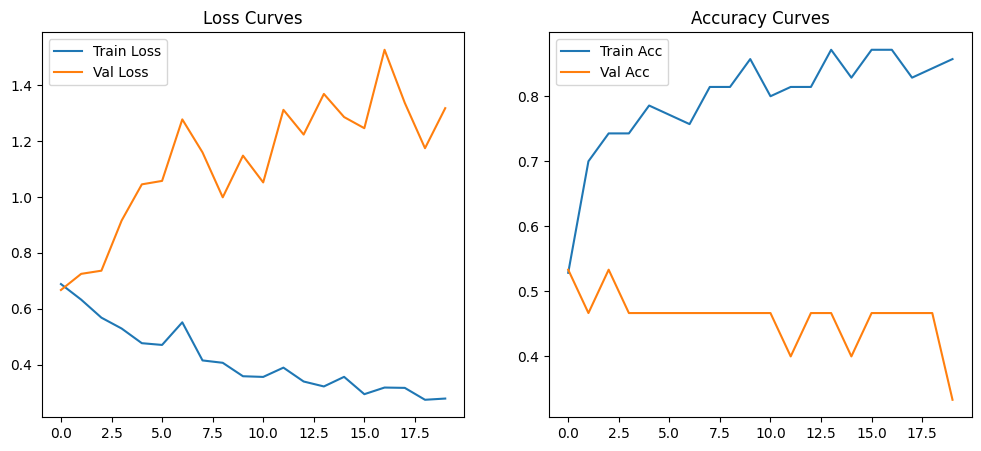

In [18]:
# Step 5: Training Loop with Epoch Logs and Curves (Fixed Import)
from torch_geometric.nn import global_mean_pool  # Added missing import

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(20):  # Reduced epochs for quick test
    model.train()
    train_loss, train_preds, train_labels = 0, [], []
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        train_preds.extend(out.argmax(dim=1).cpu().numpy())
        train_labels.extend(batch.y.cpu().numpy())
    
    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    model.eval()
    val_loss, val_preds, val_labels = 0, [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y)
            val_loss += loss.item()
            val_preds.extend(out.argmax(dim=1).cpu().numpy())
            val_labels.extend(batch.y.cpu().numpy())
    
    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch+1}/20 | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

# Plot curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss Curves')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy Curves')
plt.show()

In [19]:
# Step 6: Evaluation
model.eval()
test_preds, test_labels, test_times, test_probs = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        probs = torch.softmax(out, dim=1)[:, 1]
        test_preds.extend(out.argmax(dim=1).cpu().numpy())
        test_labels.extend(batch.y.cpu().numpy())
        test_times.extend(batch.time.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

acc = accuracy_score(test_labels, test_preds)
auroc = roc_auc_score(test_labels, test_probs)
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
auprc = np.trapz(recall, precision)
f1 = f1_score(test_labels, test_preds)
c_index = concordance_index(test_times, -np.array(test_probs), np.array(test_labels))

print(f'Test Acc: {acc:.4f} | AUROC: {auroc:.4f} | AUPRC: {auprc:.4f} | F1: {f1:.4f} | C-Index: {c_index:.4f}')


Test Acc: 0.6667 | AUROC: 0.6667 | AUPRC: 0.1271 | F1: 0.6667 | C-Index: 0.6032


In [20]:
# Step 7: Simple Ablation (No GNN vs Full) - Fixed Graph-Level Pooling
from torch_geometric.nn import global_mean_pool  # Ensure import (if not already)

class NoGNN(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.lstm = LSTM(in_channels - 1, 64, batch_first=True)
        self.lin = nn.Linear(64, out_channels)
    
    def forward(self, data):
        x, batch = data.x, data.batch
        x = x[:, :-1]  # Exclude temporal [total_nodes, 768]
        x, _ = self.lstm(x.unsqueeze(1))  # [total_nodes, 1, 64]
        x = x.squeeze(1)  # [total_nodes, 64]
        x = global_mean_pool(x, batch)  # FIXED: Pool to graph-level [batch_size, 64]
        return self.lin(x)

no_gnn = NoGNN(769, 2).to(device)
opt_ab = optim.Adam(no_gnn.parameters(), lr=0.001)
crit_ab = nn.CrossEntropyLoss()

# Quick train ablation (5 epochs)
for _ in range(5):
    no_gnn.train()
    for batch in train_loader:
        batch = batch.to(device)
        opt_ab.zero_grad()
        out = no_gnn(batch)
        loss = crit_ab(out, batch.y)
        loss.backward()
        opt_ab.step()

# Eval ablation
no_gnn.eval()
ab_preds, ab_labels, ab_times, ab_probs = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = no_gnn(batch)
        probs = torch.softmax(out, dim=1)[:, 1]
        ab_preds.extend(out.argmax(dim=1).cpu().numpy())
        ab_labels.extend(batch.y.cpu().numpy())
        ab_times.extend(batch.time.cpu().numpy())
        ab_probs.extend(probs.cpu().numpy())

ab_acc = accuracy_score(ab_labels, ab_preds)
ab_auroc = roc_auc_score(ab_labels, ab_probs)
ab_c_index = concordance_index(ab_times, -np.array(ab_probs), np.array(ab_labels))

print(f'Ablation NoGNN - Acc: {ab_acc:.4f} | AUROC: {ab_auroc:.4f} | C-Index: {ab_c_index:.4f}')

Ablation NoGNN - Acc: 0.6667 | AUROC: 0.6667 | C-Index: 0.6667


In [21]:
# Step 8: Basic Explainer (Gradient-Based Attribution) - Fixed Training Mode
def explain_sample(model, data):
    data = data.to(device)
    data.x.requires_grad_(True)  # Gradients on input features (x)
    model.train()  # FIXED: Temporarily set to train mode for RNN backward
    out = model(data)
    out[0, :].sum().backward()  # Backprop from output (sum for all classes)
    grad = data.x.grad[0]  # Gradients on first node's features
    model.eval()  # Switch back to eval mode
    data.x.grad.zero_()  # Clear gradients
    return grad.abs().topk(10).values  # Top 10 absolute gradients (attributions)

sample_data = graphs[0]
explain = explain_sample(model, sample_data)
print(f'Sample Explanation (Top 10 feature attributions): {explain}')

Sample Explanation (Top 10 feature attributions): tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
